In [24]:
import sys
import pandas as pd
import os
import numpy as np
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

ROOT = Path("..") if Path("../configs").exists() else Path(".")
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from src.hcm_transcription.mapping import MAPPING
from src.hcm_transcription.utils import ORNAMENT_MAPPING, df_to_anno, extract_ornament_segments

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
raga_names = MAPPING.keys()
data_home = str(ROOT)
annotation_base = str(ROOT / "Ornamentation-In-Hindustani-Vocals-Dataset")

segments = extract_ornament_segments(raga_names, data_home, annotation_base)

# Inspect one segment
print(segments[0]['label'])
print(segments[0]['pitch_curve'])

Loading Aahir Bhairon...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Aahir Bhairon/Aahir Bhairon.pitch.txt
  Found 109 target ornaments out of 149 total
Loading Bairagi...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Bairagi/Bairagi.pitch.txt
  Found 65 target ornaments out of 89 total
Loading Bhairavi Dadra...
  Pitch: ../saraga1.5_hindustani/Raag Bihag & Bhairavi Dadra by Omkar Dadarkar/Bhairavi Dadra/Bhairavi Dadra.pitch.txt
  Found 36 target ornaments out of 96 total
Loading Irani Bhairavi...
  Pitch: ../saraga1.5_hindustani/New Signature by Brajeshwar Mukherjee/Irani Bhairavi Thumri/Irani Bhairavi Thumri.pitch.txt
  Found 83 target ornaments out of 103 total
Loading Kalavati...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Kalavati/Kalavati.pitch.txt
  Found 96 target ornaments out of 137 total
Loading Malkauns...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Malkauns

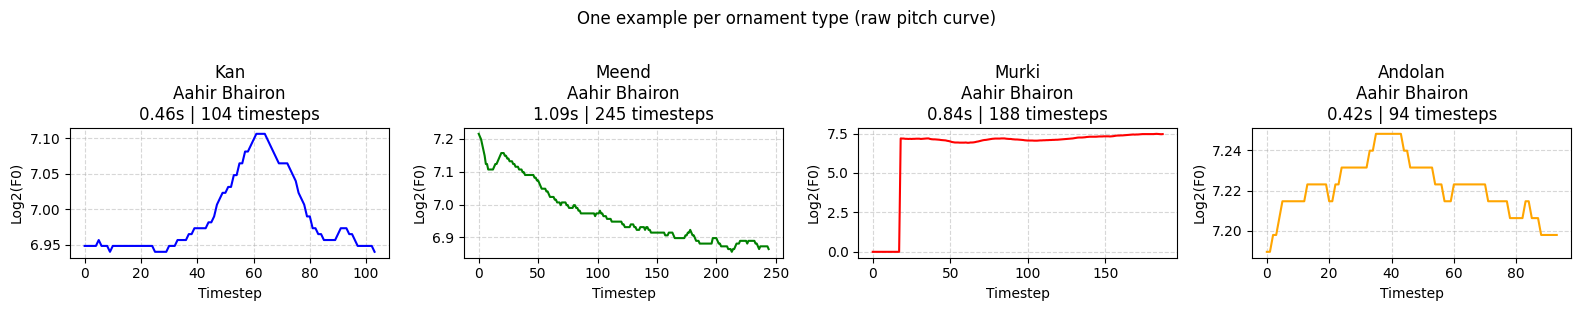

In [4]:
# Plot one example per class
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
colors = {"Kan": "blue", "Meend": "green", "Murki": "red", "Andolan": "orange"}

for ax, label in zip(axes, ["Kan", "Meend", "Murki", "Andolan"]):
    # Find first example of this label
    example = next((s for s in segments if s['label'] == label), None)
    
    if example is None:
        ax.set_title(f"{label}\n(not found)")
        continue
    
    curve = example['pitch_curve']
    ax.plot(curve, color=colors[label], linewidth=1.5)
    ax.set_title(f"{label}\n{example['raga']}\n{example['duration']:.2f}s | {len(curve)} timesteps")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Log2(F0)")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("One example per ornament type (raw pitch curve)", y=1.02)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

# Build summary dataframe
df_segments = pd.DataFrame([{k: v for k, v in s.items() if k != "pitch_curve"} for s in segments])
df_segments['num_timesteps'] = [len(s['pitch_curve']) for s in segments]

print("=== Class Distribution ===")
print(df_segments['label'].value_counts())

print("\n=== Duration Stats per Class (seconds) ===")
print(df_segments.groupby('label')['duration'].describe().round(3))

print("\n=== Timestep Stats per Class ===")
print(df_segments.groupby('label')['num_timesteps'].describe().round(1))

print("\n=== Duration Stats per Raga ===")
print(df_segments.groupby('raga')['duration'].describe().round(3))

=== Class Distribution ===
label
Kan        388
Meend      379
Murki      159
Andolan     33
Name: count, dtype: int64

=== Duration Stats per Class (seconds) ===
         count   mean    std    min    25%    50%    75%    max
label                                                          
Andolan   33.0  0.970  1.051  0.107  0.270  0.418  1.443  4.644
Kan      388.0  0.400  0.304  0.065  0.211  0.305  0.505  2.771
Meend    379.0  0.760  0.430  0.174  0.495  0.668  0.906  4.040
Murki    159.0  0.957  0.686  0.017  0.441  0.784  1.297  4.060

=== Timestep Stats per Class ===
         count   mean    std   min    25%    50%    75%     max
label                                                          
Andolan   33.0  218.3  236.7  24.0   60.0   94.0  325.0  1045.0
Kan      388.0   89.9   68.4  14.0   47.8   68.0  114.0   624.0
Meend    379.0  171.1   96.8  39.0  111.0  151.0  204.5   909.0
Murki    159.0  215.5  154.4   4.0   99.5  176.0  292.0   913.0

=== Duration Stats per Raga ===
  

In [6]:
lengths = [len(s['pitch_curve']) for s in segments]
print(f"min: {min(lengths)}")
print(f"max: {max(lengths)}")
print(f"mean: {np.mean(lengths):.0f}")
print(f"95th percentile: {np.percentile(lengths, 95):.0f}")

min: 4
max: 1045
mean: 147
95th percentile: 371


In [7]:
def augment_pitch_curve(curve, noise_std=0.01, stretch_range=(0.8, 1.2)):
    """
    Applies random augmentations to a pitch curve:
    - Gaussian noise
    - Time stretching (resampling)
    """
    from scipy.signal import resample
    
    # Random time stretch
    stretch_factor = np.random.uniform(*stretch_range)
    new_length = int(len(curve) * stretch_factor)
    curve = resample(curve, new_length)
    
    # Add small Gaussian noise
    #curve = curve + np.random.normal(0, noise_std, len(curve))
    
    return curve


def augment_segments(segments, num_augmentations=2):
    """
    Augments each segment num_augmentations times and adds to dataset.
    """
    augmented = []
    for seg in segments:
        augmented.append(seg)  # keep original
        
        for _ in range(num_augmentations):
            aug_curve = augment_pitch_curve(seg['pitch_curve'].copy())
            augmented.append({
                "raga": seg['raga'],
                "label": seg['label'],
                "time_s": seg['time_s'],
                "time_e": seg['time_e'],
                "duration": seg['duration'],
                "pitch_curve": aug_curve
            })
    
    print(f"Original: {len(segments)} → Augmented: {len(augmented)} segments")
    return augmented

segments_aug = augment_segments(segments, num_augmentations=2)

Original: 959 → Augmented: 2877 segments


### Preprocess

In [9]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

def prepare_tcn_input(segments, fixed_length=117):
    """
    Takes raw segments from extract_ornament_segments and prepares
    fixed-length numpy arrays for TCN training.
    """
    label_map = {"Kan": 0, "Meend": 1, "Murki": 2, "Andolan": 3}
    
    X, y = [], []
    skipped = 0

    # Filter too-short segments before processing
    segments = [s for s in segments if len(s['pitch_curve']) >= 20]
    
    for seg in segments:
        curve = seg['pitch_curve']
        label = seg['label']
        
        if label not in label_map:
            skipped += 1
            continue
        
        # Normalize each curve to zero mean and unit variance
        if curve.std() > 0:
            curve = (curve - curve.mean()) / curve.std()
        
        # Pad or truncate to fixed length
        if len(curve) < fixed_length:
            curve = np.pad(curve, (0, fixed_length - len(curve)), mode='constant')
        else:
            curve = curve[:fixed_length]
        
        X.append(curve)
        y.append(label_map[label])
    
    X = np.array(X, dtype=np.float32)[:, np.newaxis, :]  # (N, 1, fixed_length)
    y = np.array(y, dtype=np.int64)
    
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Skipped: {skipped}")
    print(f"Label distribution: { {k: int((y==v).sum()) for k,v in label_map.items()} }")
    
    return X, y, label_map


def get_dataloaders(X, y, batch_size=16, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    
    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)
    
    print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
    return train_loader, test_loader

In [10]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.norm1 = nn.BatchNorm1d(channels)
        self.norm2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        out = self.relu(self.norm1(self.conv1(x)[:, :, :x.size(2)]))
        out = self.dropout(out)
        out = self.relu(self.norm2(self.conv2(out)[:, :, :x.size(2)]))
        return self.relu(out + x)  # residual connection


class OrnamentTCN(nn.Module):
    def __init__(self, input_size=1, num_classes=4, channels=32, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)  # collapses any length to 1
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = out.mean(dim=2)  # global average pooling
        return self.classifier(out)

In [11]:
from sklearn.utils.class_weight import compute_class_weight

def train_tcn(train_loader, test_loader, num_classes=4, epochs=30):
    model = OrnamentTCN(input_size=1, num_classes=num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Handle class imbalance
    all_labels = train_loader.dataset.tensors[1].numpy()
    weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += len(yb)
        
        # Evaluate
        model.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                preds = model(xb)
                test_correct += (preds.argmax(1) == yb).sum().item()
                test_total += len(yb)
        
        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {train_loss/len(train_loader):.4f} | "
              f"Train Acc: {correct/total:.3f} | "
              f"Test Acc: {test_correct/test_total:.3f}")
    
    return model

In [12]:
# After running extract_ornament_segments
X, y, label_map = prepare_tcn_input(segments_aug, fixed_length=200)
train_loader, test_loader = get_dataloaders(X, y, batch_size=16)
model = train_tcn(train_loader, test_loader, epochs=30)

X shape: (2865, 1, 200)
y shape: (2865,)
Skipped: 0
Label distribution: {'Kan': 1155, 'Meend': 1137, 'Murki': 474, 'Andolan': 99}
Train: 2292 | Test: 573
Epoch 01 | Loss: 1.2906 | Train Acc: 0.554 | Test Acc: 0.572
Epoch 02 | Loss: 1.1955 | Train Acc: 0.589 | Test Acc: 0.581
Epoch 03 | Loss: 1.1292 | Train Acc: 0.614 | Test Acc: 0.651
Epoch 04 | Loss: 1.0946 | Train Acc: 0.627 | Test Acc: 0.634
Epoch 05 | Loss: 1.0482 | Train Acc: 0.640 | Test Acc: 0.618
Epoch 06 | Loss: 1.0145 | Train Acc: 0.653 | Test Acc: 0.656
Epoch 07 | Loss: 0.9645 | Train Acc: 0.665 | Test Acc: 0.665
Epoch 08 | Loss: 0.9357 | Train Acc: 0.661 | Test Acc: 0.681
Epoch 09 | Loss: 0.9066 | Train Acc: 0.664 | Test Acc: 0.551
Epoch 10 | Loss: 0.8931 | Train Acc: 0.670 | Test Acc: 0.621
Epoch 11 | Loss: 0.8762 | Train Acc: 0.675 | Test Acc: 0.689
Epoch 12 | Loss: 0.8331 | Train Acc: 0.681 | Test Acc: 0.639
Epoch 13 | Loss: 0.8235 | Train Acc: 0.681 | Test Acc: 0.253
Epoch 14 | Loss: 0.8084 | Train Acc: 0.693 | Test Acc

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, test_loader, label_map):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            xb, yb = batch[0], batch[1]
            preds = model(xb).argmax(1)
            all_preds.extend(preds.numpy())
            all_labels.extend(yb.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    idx_to_label = {v: k for k, v in label_map.items()}
    target_names = [idx_to_label[i] for i in range(len(label_map))]
    
    # Classification report
    print("=== Classification Report ===")
    print(classification_report(all_labels, all_preds, target_names=target_names))
    
    # Explicit per-class metrics
    precision = precision_score(all_labels, all_preds, average=None)
    recall    = recall_score(all_labels, all_preds, average=None)
    f1        = f1_score(all_labels, all_preds, average=None)
    
    print("=== Per-class Metrics ===")
    for i, name in enumerate(target_names):
        print(f"{name:10s} | Precision: {precision[i]:.3f} | Recall: {recall[i]:.3f} | F1: {f1[i]:.3f}")
    
    # Macro averages
    print(f"\n{'Macro avg':10s} | Precision: {precision.mean():.3f} | Recall: {recall.mean():.3f} | F1: {f1.mean():.3f}")
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    return all_preds, all_labels, precision, recall, f1

=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.74      0.65      0.69       231
       Meend       0.77      0.70      0.73       227
       Murki       0.75      0.82      0.78        95
     Andolan       0.29      0.85      0.44        20

    accuracy                           0.71       573
   macro avg       0.64      0.76      0.66       573
weighted avg       0.74      0.71      0.72       573

=== Per-class Metrics ===
Kan        | Precision: 0.737 | Recall: 0.654 | F1: 0.693
Meend      | Precision: 0.772 | Recall: 0.700 | F1: 0.734
Murki      | Precision: 0.750 | Recall: 0.821 | F1: 0.784
Andolan    | Precision: 0.293 | Recall: 0.850 | F1: 0.436

Macro avg  | Precision: 0.638 | Recall: 0.756 | F1: 0.662


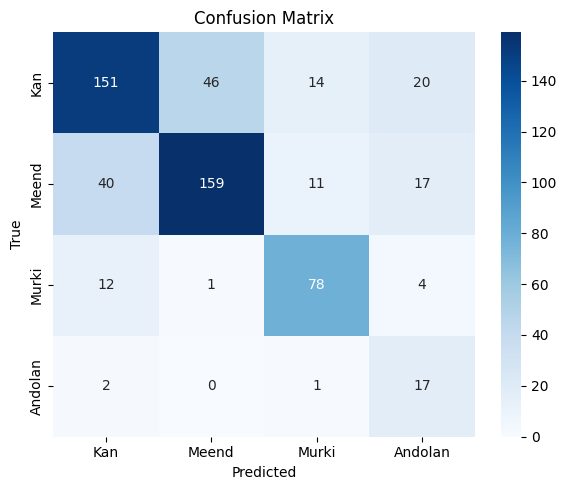

Precision: [0.73658537 0.77184466 0.75       0.29310345]
Recall:    [0.65367965 0.70044053 0.82105263 0.85      ]
F1:        [0.69266055 0.73441109 0.7839196  0.43589744]


In [14]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)

#### Without data augmentation 

##### loss:0.9083, trainacc = 0.643, testacc = 0.589
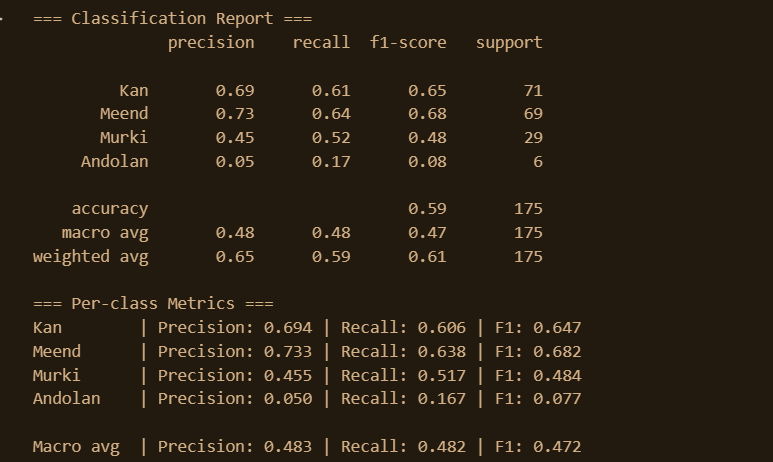

#### Cross validation for augmented data

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def cross_validate_tcn(X, y, label_map, n_splits=5, epochs=30, batch_size=16):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    idx_to_label = {v: k for k, v in label_map.items()}
    target_names = [idx_to_label[i] for i in range(len(label_map))]
    
    fold_results = []
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X.reshape(len(X), -1), y)):
        print(f"\n{'='*50}")
        print(f"FOLD {fold+1}/{n_splits}")
        print(f"{'='*50}")
        
        # Split using indices directly on numpy arrays
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Use TensorDataset like your get_dataloaders
        train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
        test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))
        
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        test_loader  = DataLoader(test_ds,  batch_size=batch_size)
        
        # Train
        model = train_tcn(train_loader, test_loader,
                          num_classes=len(label_map), epochs=epochs)
        
        # Evaluate
        print(f"\n--- Fold {fold+1} Evaluation ---")
        all_preds, all_labels, precision, recall, f1 = evaluate_model(
            model, test_loader, label_map
        )
        
        acc    = (all_preds == all_labels).mean()
        f1_mac = f1.mean()
        
        fold_results.append({
            "fold": fold + 1,
            "accuracy": acc,
            "macro_f1": f1_mac,
            "precision": precision,
            "recall": recall,
            "per_class_f1": f1,
            "all_preds": all_preds,
            "all_labels": all_labels
        })
    
    # Summary
    print(f"\n{'='*50}")
    print("CROSS VALIDATION SUMMARY")
    print(f"{'='*50}")
    
    accs = [r['accuracy'] for r in fold_results]
    f1s  = [r['macro_f1'] for r in fold_results]
    print(f"\nAccuracy: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
    print(f"Macro F1: {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
    
    print("\nPer-class metrics across folds (mean ± std):")
    print(f"{'Class':10s} | {'Precision':>15s} | {'Recall':>15s} | {'F1':>15s}")
    print("-" * 65)
    for i, name in enumerate(target_names):
        prec_scores = [r['precision'][i]    for r in fold_results]
        rec_scores  = [r['recall'][i]       for r in fold_results]
        f1_scores   = [r['per_class_f1'][i] for r in fold_results]
        print(f"{name:10s} | "
              f"{np.mean(prec_scores):.3f} ± {np.std(prec_scores):.3f}  | "
              f"{np.mean(rec_scores):.3f} ± {np.std(rec_scores):.3f}  | "
              f"{np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
    
    # Combined confusion matrix
    all_preds_combined  = np.concatenate([r['all_preds']  for r in fold_results])
    all_labels_combined = np.concatenate([r['all_labels'] for r in fold_results])
    
    cm = confusion_matrix(all_labels_combined, all_preds_combined)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Combined Confusion Matrix (all folds)")
    plt.tight_layout()
    plt.show()
    
    return fold_results

X shape: (2865, 1, 117)
y shape: (2865,)
Skipped: 0
Label distribution: {'Kan': 1155, 'Meend': 1137, 'Murki': 474, 'Andolan': 99}

FOLD 1/5
Epoch 01 | Loss: 1.2908 | Train Acc: 0.519 | Test Acc: 0.553
Epoch 02 | Loss: 1.2119 | Train Acc: 0.557 | Test Acc: 0.417
Epoch 03 | Loss: 1.1743 | Train Acc: 0.567 | Test Acc: 0.579
Epoch 04 | Loss: 1.1177 | Train Acc: 0.583 | Test Acc: 0.494
Epoch 05 | Loss: 1.1105 | Train Acc: 0.586 | Test Acc: 0.597
Epoch 06 | Loss: 1.0844 | Train Acc: 0.607 | Test Acc: 0.611
Epoch 07 | Loss: 1.0440 | Train Acc: 0.613 | Test Acc: 0.588
Epoch 08 | Loss: 1.0241 | Train Acc: 0.600 | Test Acc: 0.571
Epoch 09 | Loss: 1.0282 | Train Acc: 0.606 | Test Acc: 0.621
Epoch 10 | Loss: 0.9987 | Train Acc: 0.629 | Test Acc: 0.644
Epoch 11 | Loss: 0.9543 | Train Acc: 0.616 | Test Acc: 0.646
Epoch 12 | Loss: 0.9269 | Train Acc: 0.636 | Test Acc: 0.597
Epoch 13 | Loss: 0.9416 | Train Acc: 0.619 | Test Acc: 0.656
Epoch 14 | Loss: 0.9353 | Train Acc: 0.636 | Test Acc: 0.640
Epoch 

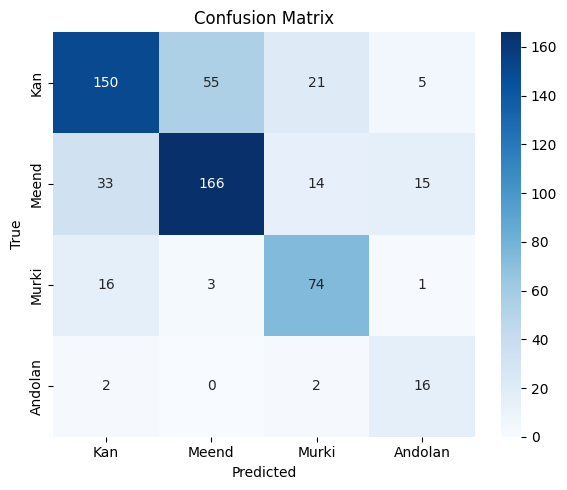


FOLD 2/5
Epoch 01 | Loss: 1.3172 | Train Acc: 0.516 | Test Acc: 0.510
Epoch 02 | Loss: 1.2074 | Train Acc: 0.564 | Test Acc: 0.647
Epoch 03 | Loss: 1.1600 | Train Acc: 0.575 | Test Acc: 0.613
Epoch 04 | Loss: 1.1352 | Train Acc: 0.580 | Test Acc: 0.654
Epoch 05 | Loss: 1.0963 | Train Acc: 0.586 | Test Acc: 0.632
Epoch 06 | Loss: 1.0762 | Train Acc: 0.590 | Test Acc: 0.609
Epoch 07 | Loss: 1.0328 | Train Acc: 0.601 | Test Acc: 0.613
Epoch 08 | Loss: 1.0172 | Train Acc: 0.607 | Test Acc: 0.630
Epoch 09 | Loss: 0.9808 | Train Acc: 0.622 | Test Acc: 0.677
Epoch 10 | Loss: 0.9548 | Train Acc: 0.622 | Test Acc: 0.651
Epoch 11 | Loss: 0.9356 | Train Acc: 0.622 | Test Acc: 0.681
Epoch 12 | Loss: 0.9206 | Train Acc: 0.627 | Test Acc: 0.677
Epoch 13 | Loss: 0.9212 | Train Acc: 0.640 | Test Acc: 0.698
Epoch 14 | Loss: 0.8732 | Train Acc: 0.635 | Test Acc: 0.667
Epoch 15 | Loss: 0.8643 | Train Acc: 0.640 | Test Acc: 0.693
Epoch 16 | Loss: 0.8390 | Train Acc: 0.638 | Test Acc: 0.726
Epoch 17 | Los

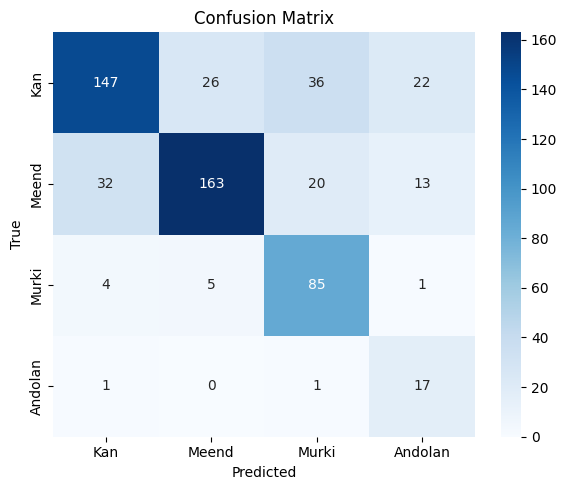


FOLD 3/5
Epoch 01 | Loss: 1.3201 | Train Acc: 0.486 | Test Acc: 0.550
Epoch 02 | Loss: 1.2184 | Train Acc: 0.565 | Test Acc: 0.522
Epoch 03 | Loss: 1.1486 | Train Acc: 0.558 | Test Acc: 0.620
Epoch 04 | Loss: 1.1145 | Train Acc: 0.590 | Test Acc: 0.532
Epoch 05 | Loss: 1.0568 | Train Acc: 0.583 | Test Acc: 0.599
Epoch 06 | Loss: 1.0192 | Train Acc: 0.603 | Test Acc: 0.634
Epoch 07 | Loss: 1.0124 | Train Acc: 0.619 | Test Acc: 0.579
Epoch 08 | Loss: 0.9874 | Train Acc: 0.612 | Test Acc: 0.599
Epoch 09 | Loss: 0.9537 | Train Acc: 0.619 | Test Acc: 0.665
Epoch 10 | Loss: 0.9390 | Train Acc: 0.637 | Test Acc: 0.623
Epoch 11 | Loss: 0.9081 | Train Acc: 0.652 | Test Acc: 0.672
Epoch 12 | Loss: 0.9130 | Train Acc: 0.647 | Test Acc: 0.646
Epoch 13 | Loss: 0.8692 | Train Acc: 0.659 | Test Acc: 0.661
Epoch 14 | Loss: 0.8499 | Train Acc: 0.660 | Test Acc: 0.674
Epoch 15 | Loss: 0.8704 | Train Acc: 0.658 | Test Acc: 0.654
Epoch 16 | Loss: 0.8521 | Train Acc: 0.660 | Test Acc: 0.688
Epoch 17 | Los

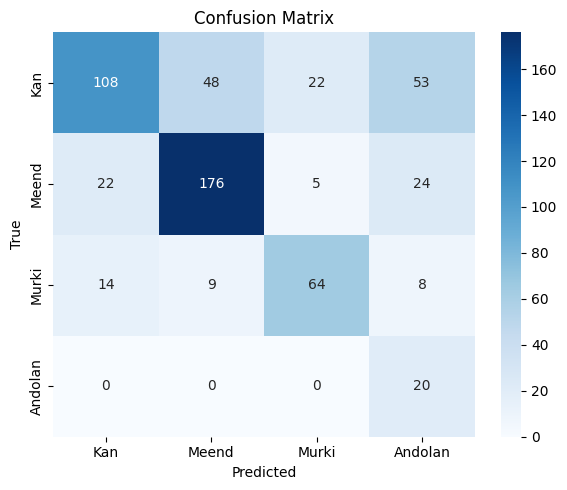


FOLD 4/5
Epoch 01 | Loss: 1.3087 | Train Acc: 0.507 | Test Acc: 0.353
Epoch 02 | Loss: 1.2095 | Train Acc: 0.558 | Test Acc: 0.431
Epoch 03 | Loss: 1.1529 | Train Acc: 0.576 | Test Acc: 0.527
Epoch 04 | Loss: 1.1200 | Train Acc: 0.583 | Test Acc: 0.599
Epoch 05 | Loss: 1.0827 | Train Acc: 0.605 | Test Acc: 0.607
Epoch 06 | Loss: 1.0412 | Train Acc: 0.601 | Test Acc: 0.635
Epoch 07 | Loss: 1.0484 | Train Acc: 0.611 | Test Acc: 0.602
Epoch 08 | Loss: 1.0078 | Train Acc: 0.622 | Test Acc: 0.642
Epoch 09 | Loss: 0.9824 | Train Acc: 0.616 | Test Acc: 0.572
Epoch 10 | Loss: 0.9600 | Train Acc: 0.626 | Test Acc: 0.634
Epoch 11 | Loss: 0.9504 | Train Acc: 0.629 | Test Acc: 0.656
Epoch 12 | Loss: 0.9278 | Train Acc: 0.640 | Test Acc: 0.632
Epoch 13 | Loss: 0.9166 | Train Acc: 0.636 | Test Acc: 0.639
Epoch 14 | Loss: 0.9065 | Train Acc: 0.641 | Test Acc: 0.637
Epoch 15 | Loss: 0.8657 | Train Acc: 0.658 | Test Acc: 0.653
Epoch 16 | Loss: 0.8473 | Train Acc: 0.651 | Test Acc: 0.634
Epoch 17 | Los

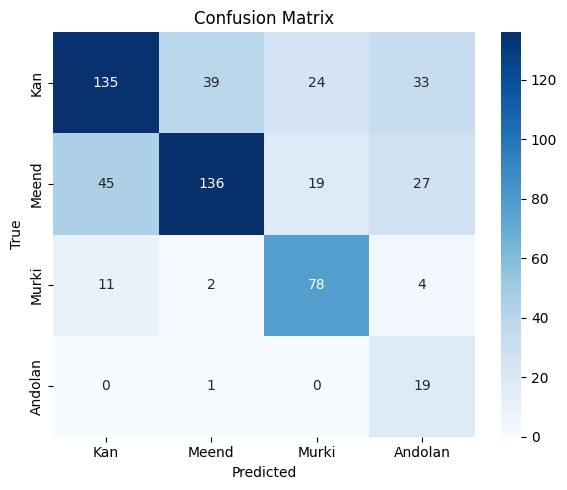


FOLD 5/5
Epoch 01 | Loss: 1.3624 | Train Acc: 0.462 | Test Acc: 0.572
Epoch 02 | Loss: 1.2224 | Train Acc: 0.545 | Test Acc: 0.583
Epoch 03 | Loss: 1.1563 | Train Acc: 0.554 | Test Acc: 0.625
Epoch 04 | Loss: 1.1213 | Train Acc: 0.571 | Test Acc: 0.518
Epoch 05 | Loss: 1.0777 | Train Acc: 0.598 | Test Acc: 0.640
Epoch 06 | Loss: 1.0279 | Train Acc: 0.582 | Test Acc: 0.660
Epoch 07 | Loss: 1.0368 | Train Acc: 0.596 | Test Acc: 0.588
Epoch 08 | Loss: 0.9722 | Train Acc: 0.614 | Test Acc: 0.536
Epoch 09 | Loss: 0.9657 | Train Acc: 0.600 | Test Acc: 0.527
Epoch 10 | Loss: 0.9557 | Train Acc: 0.617 | Test Acc: 0.646
Epoch 11 | Loss: 0.9331 | Train Acc: 0.608 | Test Acc: 0.663
Epoch 12 | Loss: 0.9059 | Train Acc: 0.627 | Test Acc: 0.647
Epoch 13 | Loss: 0.9034 | Train Acc: 0.622 | Test Acc: 0.688
Epoch 14 | Loss: 0.8601 | Train Acc: 0.632 | Test Acc: 0.632
Epoch 15 | Loss: 0.8844 | Train Acc: 0.645 | Test Acc: 0.642
Epoch 16 | Loss: 0.8361 | Train Acc: 0.641 | Test Acc: 0.656
Epoch 17 | Los

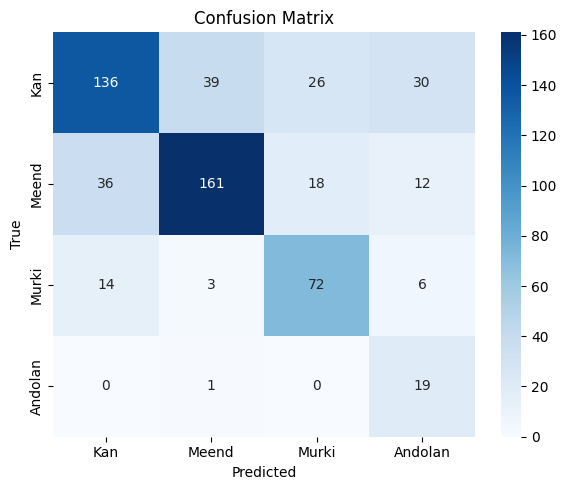


CROSS VALIDATION SUMMARY

Accuracy: 0.678 ± 0.032
Macro F1: 0.633 ± 0.036

Per-class metrics across folds (mean ± std):
Class      |       Precision |          Recall |              F1
-----------------------------------------------------------------
Kan        | 0.747 ± 0.030  | 0.585 ± 0.064  | 0.654 ± 0.047
Meend      | 0.778 ± 0.035  | 0.705 ± 0.058  | 0.738 ± 0.036
Murki      | 0.647 ± 0.036  | 0.787 ± 0.073  | 0.706 ± 0.017
Andolan    | 0.291 ± 0.084  | 0.919 ± 0.068  | 0.432 ± 0.084


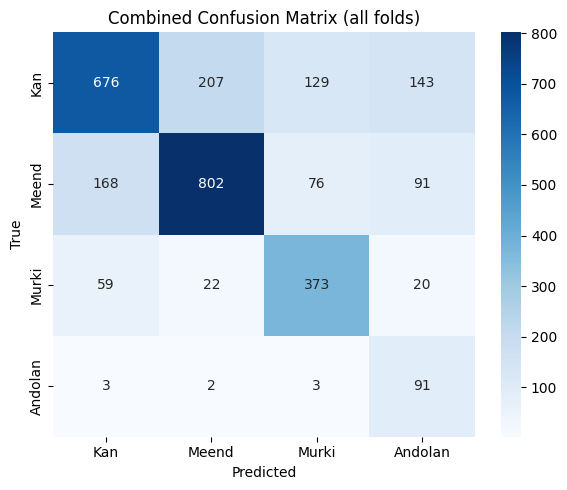

In [16]:
X, y, label_map = prepare_tcn_input(segments_aug, fixed_length=117)
fold_results = cross_validate_tcn(X, y, label_map, n_splits=5, epochs=30)

### Adaptive window

In [17]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
def prepare_tcn_input(segments, min_length=20):
    label_map = {"Kan": 0, "Meend": 1, "Murki": 2, "Andolan": 3}
    
    X, y = [], []
    skipped = 0
    
    # Filter too short
    segments = [s for s in segments if len(s['pitch_curve']) >= min_length]
    
    for seg in segments:
        curve = seg['pitch_curve'].copy()
        label = seg['label']
        
        if label not in label_map:
            skipped += 1
            continue
        
        # Normalize
        if curve.std() > 0:
            curve = (curve - curve.mean()) / curve.std()
        else:
            skipped += 1
            continue
        
        X.append(torch.tensor(curve, dtype=torch.float32).unsqueeze(0))  # (1, length)
        y.append(label_map[label])
    
    y = torch.tensor(y, dtype=torch.int64)
    
    print(f"Total segments: {len(X)}")
    print(f"Skipped: {skipped}")
    print(f"Label distribution: { {k: int((y==v).sum()) for k,v in label_map.items()} }")
    
    return X, y, label_map  # X is now a list of variable length tensors

In [18]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """Pads sequences in each batch to the longest in that batch."""
    X_batch, y_batch = zip(*batch)
    lengths = torch.tensor([x.shape[-1] for x in X_batch])
    
    # Pad to longest sequence in this batch
    X_padded = pad_sequence(
        [x.squeeze(0) for x in X_batch], 
        batch_first=True
    ).unsqueeze(1)  # (batch, 1, max_len_in_batch)
    
    return X_padded, torch.tensor(y_batch), lengths

In [19]:
from torch.utils.data import Dataset

class OrnamentDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def get_dataloaders(X, y, batch_size=16, test_size=0.2):
    # Split indices
    from sklearn.model_selection import train_test_split
    indices = list(range(len(X)))
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, 
        stratify=y.numpy(), random_state=42
    )
    
    X_train = [X[i] for i in train_idx]
    X_test  = [X[i] for i in test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]
    
    train_ds = OrnamentDataset(X_train, y_train)
    test_ds  = OrnamentDataset(X_test,  y_test)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, 
                              shuffle=True, collate_fn=collate_fn)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, 
                              collate_fn=collate_fn)
    
    print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
    return train_loader, test_loader

In [20]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.norm1 = nn.BatchNorm1d(channels)
        self.norm2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        out = self.relu(self.norm1(self.conv1(x)[:, :, :x.size(2)]))
        out = self.dropout(out)
        out = self.relu(self.norm2(self.conv2(out)[:, :, :x.size(2)]))
        return self.relu(out + x)  # residual connection

class OrnamentTCN(nn.Module):
    def __init__(self, input_size=1, num_classes=4, channels=32, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)  # handles any length
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = self.adaptive_pool(out).squeeze(-1)  # (batch, channels)
        return self.classifier(out)

In [21]:
from sklearn.utils.class_weight import compute_class_weight

def train_tcn(train_loader, test_loader, num_classes=4, epochs=30):
    model = OrnamentTCN(input_size=1, num_classes=num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Handle class imbalance
    all_labels = train_loader.dataset.y.numpy()
    weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))
    
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for xb, yb, lengths in train_loader:  # unpack lengths too
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += len(yb)
        # Evaluate
        model.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for xb, yb, lengths in test_loader:
                preds = model(xb)
                test_correct += (preds.argmax(1) == yb).sum().item()
                test_total += len(yb)
        
        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {train_loss/len(train_loader):.4f} | "
              f"Train Acc: {correct/total:.3f} | "
              f"Test Acc: {test_correct/test_total:.3f}")
    
    return model

In [22]:
X, y, label_map = prepare_tcn_input(segments, min_length=20)
train_loader, test_loader = get_dataloaders(X, y, batch_size=16)
model = train_tcn(train_loader, test_loader, epochs=30)

Total segments: 956
Skipped: 0
Label distribution: {'Kan': 386, 'Meend': 379, 'Murki': 158, 'Andolan': 33}
Train: 764 | Test: 192
Epoch 01 | Loss: 1.3384 | Train Acc: 0.482 | Test Acc: 0.562
Epoch 02 | Loss: 1.2494 | Train Acc: 0.577 | Test Acc: 0.547
Epoch 03 | Loss: 1.2083 | Train Acc: 0.592 | Test Acc: 0.552
Epoch 04 | Loss: 1.1974 | Train Acc: 0.614 | Test Acc: 0.422
Epoch 05 | Loss: 1.1504 | Train Acc: 0.619 | Test Acc: 0.578
Epoch 06 | Loss: 1.1267 | Train Acc: 0.620 | Test Acc: 0.568
Epoch 07 | Loss: 1.1216 | Train Acc: 0.637 | Test Acc: 0.615
Epoch 08 | Loss: 1.0979 | Train Acc: 0.649 | Test Acc: 0.599
Epoch 09 | Loss: 1.0864 | Train Acc: 0.643 | Test Acc: 0.589
Epoch 10 | Loss: 1.0800 | Train Acc: 0.644 | Test Acc: 0.401
Epoch 11 | Loss: 1.0517 | Train Acc: 0.662 | Test Acc: 0.427
Epoch 12 | Loss: 1.0240 | Train Acc: 0.666 | Test Acc: 0.573
Epoch 13 | Loss: 1.0364 | Train Acc: 0.658 | Test Acc: 0.641
Epoch 14 | Loss: 1.0226 | Train Acc: 0.639 | Test Acc: 0.411
Epoch 15 | Loss:

=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.75      0.08      0.14        77
       Meend       0.64      0.62      0.63        76
       Murki       0.79      0.47      0.59        32
     Andolan       0.07      0.86      0.12         7

    accuracy                           0.39       192
   macro avg       0.56      0.51      0.37       192
weighted avg       0.69      0.39      0.41       192

=== Per-class Metrics ===
Kan        | Precision: 0.750 | Recall: 0.078 | F1: 0.141
Meend      | Precision: 0.644 | Recall: 0.618 | F1: 0.631
Murki      | Precision: 0.789 | Recall: 0.469 | F1: 0.588
Andolan    | Precision: 0.065 | Recall: 0.857 | F1: 0.121

Macro avg  | Precision: 0.562 | Recall: 0.506 | F1: 0.370


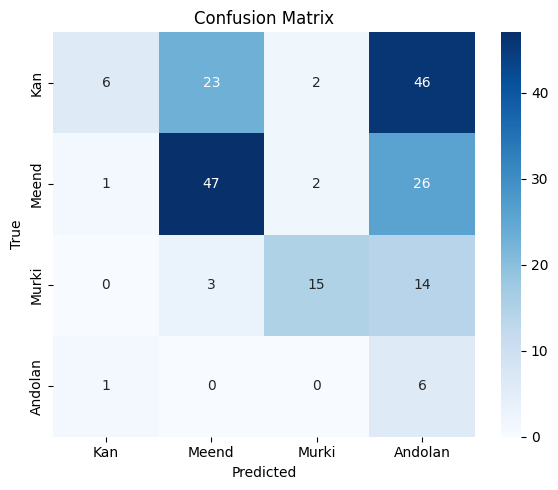

Precision: [0.75       0.64383562 0.78947368 0.06521739]
Recall:    [0.07792208 0.61842105 0.46875    0.85714286]
F1:        [0.14117647 0.63087248 0.58823529 0.12121212]


In [23]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)